# 04d — Fine-tuning multitarea del D10Sformer

**Proyecto:** D10Sformer — MIA305 (UdeSA, 2026)  
**Fase:** 4d — Fine-tuning de las heads (Result + Score + MLM auxiliar) sobre el corpus de selecciones

## Objetivo

1. Partir del `best.pt` de Fase 4c (val_loss=2.07, val_acc=0.40 en MLM).
2. Activar **todas las heads**: MLM (aux, λ=0.2) + Result (principal, λ=1.0) + Score (secundario, λ=0.3).
3. Entrenar **10 épocas** sobre `finetune_train.pkl` (8.658 docs, solo selecciones).
4. **LR = 5e-5** (10× menor que pre-train, estándar BERT para fine-tuning).
5. Evaluar contra `val.pkl` y comparar contra los baselines de Fase 1 (LogReg, XGBoost, LightGBM, ELO solo).

## Por qué multitarea

- **MLM auxiliar** evita que las representaciones se desplacen demasiado lejos de las aprendidas en pre-train (regularización).
- **Result head** es la tarea principal: clasificación 3-way (home_win / draw / away_win).
- **Score head** es secundaria (36 clases): le da al modelo señal complementaria sobre la distribución de goles.

Esto es el camino canónico BERT (Devlin et al., 2018 §3.2).

---
## 1. Setup + GPU

In [7]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/d10sformer'
except ImportError:
    import os
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/d10sformer


In [8]:
import torch
print(f'torch: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')
if not torch.cuda.is_available():
    raise RuntimeError('Necesitamos GPU. Runtime → Change runtime type → T4.')
print(f'GPU: {torch.cuda.get_device_name(0)}')

torch: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4


In [9]:
import sys, json, pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader

ROOT = Path(PROJECT_ROOT)
sys.path.insert(0, str(ROOT / 'src'))

DATA_PROCESSED = ROOT / 'data' / 'processed'
CORPUS_DIR = DATA_PROCESSED / 'corpus'
VOCAB_PATH = DATA_PROCESSED / 'vocab.json'
CKPT_DIR = ROOT / 'checkpoints'
PRETRAIN_CKPT = CKPT_DIR / 'pretrain_5ep' / 'best.pt'

assert PRETRAIN_CKPT.exists(), f'No encuentro {PRETRAIN_CKPT}. ¿Corriste Fase 4c?'
print(f'✓ Pre-train checkpoint: {PRETRAIN_CKPT}  ({PRETRAIN_CKPT.stat().st_size / 1024**2:.1f} MB)')

from data.vocabulary import FootballVocab, RESULT_TOKENS
from data.tokenizer import MatchTokenizer
from data.dataset import MatchDataset
from data.collator import MLMCollator
from models.d10sformer import D10Sformer, D10SformerConfig
from training.trainer import Trainer, TrainerConfig, LossSpec
from eval.metrics import evaluate_all

✓ Pre-train checkpoint: /content/drive/MyDrive/d10sformer/checkpoints/pretrain_5ep/best.pt  (69.2 MB)


---
## 2. Cargar vocab + corpus de fine-tuning

In [10]:
vocab = FootballVocab.load(VOCAB_PATH)
tokenizer = MatchTokenizer(vocab, max_seq_length=80)

with open(CORPUS_DIR / 'finetune_train.pkl', 'rb') as f:
    finetune_docs = pickle.load(f)
with open(CORPUS_DIR / 'val.pkl', 'rb') as f:
    val_docs = pickle.load(f)
with open(CORPUS_DIR / 'test.pkl', 'rb') as f:
    test_docs = pickle.load(f)

print(f'Fine-tune (selecciones train): {len(finetune_docs):,}')
print(f'Val:                           {len(val_docs):,}')
print(f'Test:                          {len(test_docs):,}')

ds_train = MatchDataset(finetune_docs, tokenizer)
ds_val   = MatchDataset(val_docs, tokenizer)
ds_test  = MatchDataset(test_docs, tokenizer)

# ----------------------------------------------------------------
# Mapping ids globales del vocab → ids locales de las heads
# (la ResultHead tiene 3 clases, la ScoreHead tiene 36)
# ----------------------------------------------------------------
RESULT_VOCAB_TO_LOCAL = {
    vocab.encode('RESULT_HOME_WIN'): 0,
    vocab.encode('RESULT_DRAW'):     1,
    vocab.encode('RESULT_AWAY_WIN'): 2,
}
SCORE_VOCAB_TO_LOCAL = {}
_i = 0
for _h in range(6):
    for _a in range(6):
        SCORE_VOCAB_TO_LOCAL[vocab.encode(f'SCORE_{_h}_{_a}')] = _i
        _i += 1

class LabelMappedCollator:
    """Wraps MLMCollator and remaps result/score labels from global vocab
    ids to local head ids. Preserves the -100 sentinel."""
    def __init__(self, base):
        self.base = base
    def __call__(self, batch):
        b = self.base(batch)

        # Result: mapear cada id global al local correspondiente
        # Initialize new_r with -100 everywhere. This ensures any original
        # global IDs not explicitly mapped are treated as ignored.
        new_r = torch.full_like(b.result_labels, -100, dtype=torch.long)
        for gid, lid in RESULT_VOCAB_TO_LOCAL.items():
            # Only map the actual result global IDs to their local IDs.
            # If b.result_labels contains other values (not -100 and not a result GID),
            # they will remain -100 in new_r.
            new_r[b.result_labels == gid] = lid
        b.result_labels = new_r

        # Score
        # Initialize new_s with -100 everywhere.
        new_s = torch.full_like(b.score_labels, -100, dtype=torch.long)
        for gid, lid in SCORE_VOCAB_TO_LOCAL.items():
            new_s[b.score_labels == gid] = lid
        b.score_labels = new_s
        return b

base_collator = MLMCollator(vocab, mlm_probability=0.15, seed=42)
collator = LabelMappedCollator(base_collator)

# Sanity check del mapping antes de tirar el training
_t = collator([ds_train[0]])
assert _t.result_labels.min() >= -100 and _t.result_labels.max() < 3, \
    f'result_labels fuera de rango: {_t.result_labels}'
assert _t.score_labels.min() >= -100 and _t.score_labels.max() < 36, \
    f'score_labels fuera de rango: {_t.score_labels}'
print('✓ Mapping result/score validado: result ∈ {0,1,2}, score ∈ {0..35}')

BATCH_SIZE = 64
train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collator, num_workers=0)
val_loader   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collator, num_workers=0)
test_loader  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collator, num_workers=0)

steps_per_epoch = len(train_loader)
print(f'\nTrain batches/época: {steps_per_epoch}  (batch={BATCH_SIZE})')

Fine-tune (selecciones train): 8,658
Val:                           1,232
Test:                          1,810
✓ Mapping result/score validado: result ∈ {0,1,2}, score ∈ {0..35}

Train batches/época: 136  (batch=64)


---
## 3. Construir modelo + cargar pesos pre-entrenados

In [11]:
model_config = D10SformerConfig(
    vocab_size=len(vocab),
    d_model=256, num_layers=6, num_heads=8, d_ff=1024,
    max_seq_length=80, num_segments=8,
    dropout=0.1, attention_dropout=0.1,
    pad_token_id=vocab.encode('[PAD]'),
    tie_mlm_weights=True,
)
model = D10Sformer(model_config)

# Cargar pesos pre-entrenados
ckpt = torch.load(PRETRAIN_CKPT, map_location='cpu', weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'✓ Modelo cargado desde paso {ckpt["step"]} (pre-train val_loss={ckpt["best_val_loss"]:.4f})')
print(f'  Params: {model.num_parameters():,}')

✓ Modelo cargado desde paso 900 (pre-train val_loss=2.0678)
  Params: 6,131,920


---
## 4. Configurar Trainer con LossSpec multitarea

In [12]:
EPOCHS = 10
MAX_STEPS = steps_per_epoch * EPOCHS
print(f'EPOCHS = {EPOCHS}')
print(f'Pasos totales = {MAX_STEPS}')

trainer_config = TrainerConfig(
    lr=5e-5,                # 10× menor que pre-train
    weight_decay=0.01,
    grad_clip_norm=1.0,
    warmup_ratio=0.1,
    max_steps=MAX_STEPS,
    mixed_precision=True,
    log_every=25,
    eval_every=100,
    save_every=300,
    save_best=True,
    output_dir=str(CKPT_DIR),
    run_name='finetune_10ep',
    seed=42,
)
loss_spec = LossSpec(
    use_mlm=True,    lambda_mlm=0.2,     # auxiliar, regularizador
    use_result=True, lambda_result=1.0,  # tarea principal
    use_score=True,  lambda_score=0.3,   # secundaria
)
print(f'\nLossSpec: λ_mlm={loss_spec.lambda_mlm}, λ_result={loss_spec.lambda_result}, λ_score={loss_spec.lambda_score}')

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=trainer_config,
    loss_spec=loss_spec,
)
print(f'Device: {trainer.device}  AMP: {trainer.use_amp}')
print(f'Output: {trainer.output_dir}')

EPOCHS = 10
Pasos totales = 1360

LossSpec: λ_mlm=0.2, λ_result=1.0, λ_score=0.3
Device: cuda  AMP: True
Output: /content/drive/MyDrive/d10sformer/checkpoints/finetune_10ep


---
## 5. Fine-tuning (10 épocas)

In [13]:
import time
t0 = time.time()
trainer.train()
elapsed = time.time() - t0
print(f'\n✓ Fine-tuning completado en {elapsed/60:.1f} min ({MAX_STEPS/elapsed:.1f} step/s)')
print(f'  Best val_loss: {trainer.best_val_loss:.4f}')
print(f'  Best checkpoint: {trainer.output_dir / "best.pt"}')

[step     25/1360] lr=9.19e-06  loss=2.5817  ppl=13.22  mlm_acc=0.3878  (19.5 step/s)
[step     50/1360] lr=1.84e-05  loss=2.5298  ppl=12.55  mlm_acc=0.4000  (23.8 step/s)
[step     75/1360] lr=2.76e-05  loss=2.4818  ppl=11.96  mlm_acc=0.4037  (25.5 step/s)
[step    100/1360] lr=3.68e-05  loss=2.4591  ppl=11.69  mlm_acc=0.3788  (26.8 step/s)
[eval @ step    100] val_loss=2.4312  val_ppl=11.37  val_acc=0.3900
[step    125/1360] lr=4.60e-05  loss=2.4025  ppl=11.05  mlm_acc=0.3925  (23.1 step/s)
[step    150/1360] lr=5.00e-05  loss=2.3772  ppl=10.78  mlm_acc=0.4105  (24.1 step/s)
[step    175/1360] lr=4.99e-05  loss=2.3300  ppl=10.28  mlm_acc=0.4041  (24.9 step/s)
[step    200/1360] lr=4.97e-05  loss=2.2900  ppl=9.87  mlm_acc=0.4186  (25.1 step/s)
[eval @ step    200] val_loss=2.2693  val_ppl=9.67  val_acc=0.4064
[step    225/1360] lr=4.94e-05  loss=2.2741  ppl=9.72  mlm_acc=0.4053  (22.6 step/s)
[step    250/1360] lr=4.89e-05  loss=2.2424  ppl=9.42  mlm_acc=0.4116  (22.3 step/s)
[step   

---
## 6. Curvas de fine-tuning

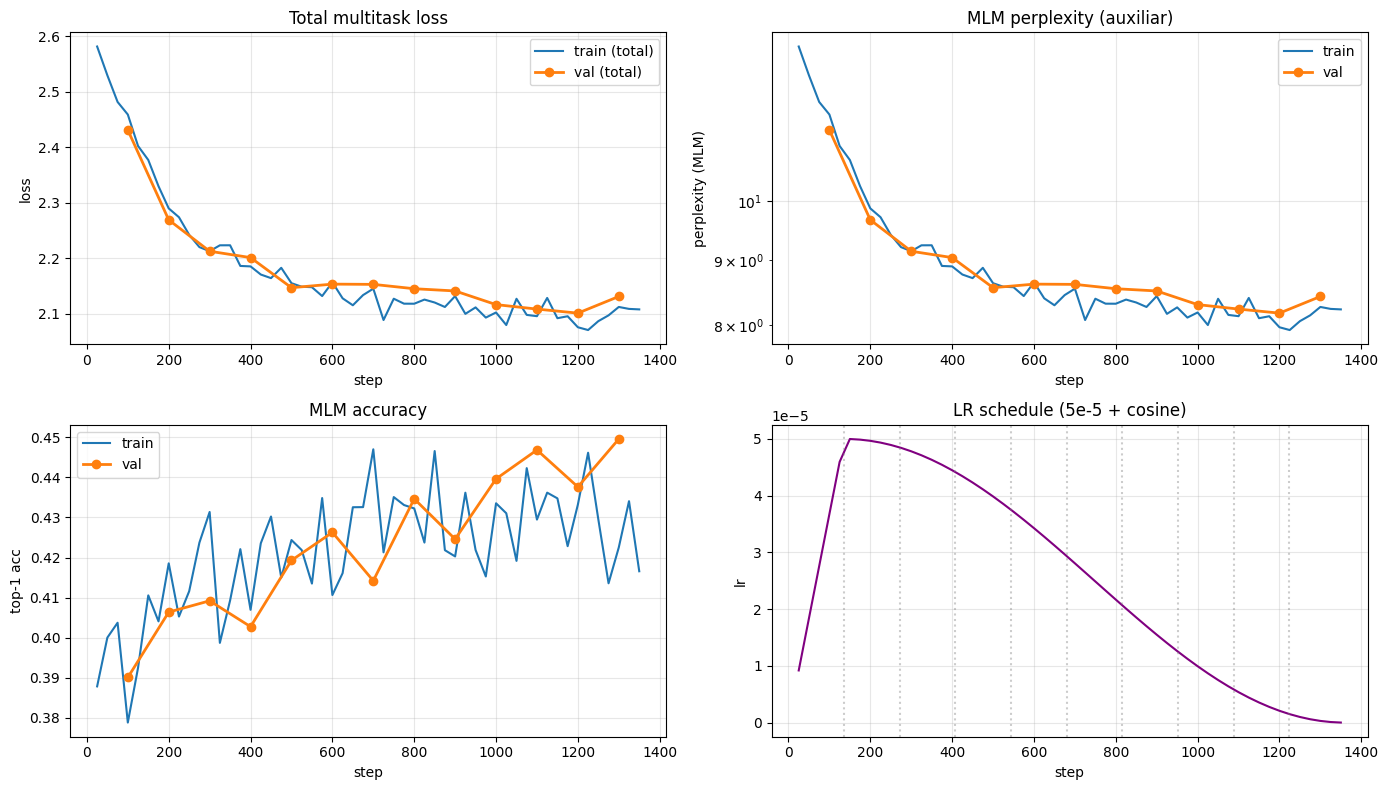

In [14]:
rows = [json.loads(l) for l in trainer.log_path.read_text().splitlines() if l.strip()]
train_rows = [r for r in rows if 'phase' not in r]
eval_rows  = [r for r in rows if r.get('phase') == 'eval']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot([r['step'] for r in train_rows], [r['loss'] for r in train_rows], label='train (total)')
if eval_rows:
    axes[0, 0].plot([r['step'] for r in eval_rows], [r['val_loss'] for r in eval_rows], 'o-', label='val (total)', linewidth=2)
axes[0, 0].set_xlabel('step'); axes[0, 0].set_ylabel('loss'); axes[0, 0].set_title('Total multitask loss')
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot([r['step'] for r in train_rows], [r['mlm_perplexity'] for r in train_rows], label='train')
if eval_rows:
    axes[0, 1].plot([r['step'] for r in eval_rows], [r['val_mlm_perplexity'] for r in eval_rows], 'o-', label='val', linewidth=2)
axes[0, 1].set_xlabel('step'); axes[0, 1].set_ylabel('perplexity (MLM)')
axes[0, 1].set_title('MLM perplexity (auxiliar)')
axes[0, 1].set_yscale('log'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot([r['step'] for r in train_rows], [r['mlm_acc'] for r in train_rows], label='train')
if eval_rows:
    axes[1, 0].plot([r['step'] for r in eval_rows], [r['val_mlm_acc'] for r in eval_rows], 'o-', label='val', linewidth=2)
axes[1, 0].set_xlabel('step'); axes[1, 0].set_ylabel('top-1 acc'); axes[1, 0].set_title('MLM accuracy')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot([r['step'] for r in train_rows], [r['lr'] for r in train_rows], color='purple')
for ep in range(1, EPOCHS):
    axes[1, 1].axvline(ep * steps_per_epoch, color='gray', linestyle=':', alpha=0.4)
axes[1, 1].set_xlabel('step'); axes[1, 1].set_ylabel('lr'); axes[1, 1].set_title('LR schedule (5e-5 + cosine)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(trainer.output_dir / 'training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 7. Evaluación detallada sobre VAL (Result head)

Recargamos el mejor checkpoint (`best.pt`) y computamos:
- Accuracy
- Log-loss (CE)
- Brier score multiclase
- ECE (Expected Calibration Error)
- Distribución de probabilidades + confusion matrix

In [15]:
@torch.no_grad()
def predict_result_probs(loader):
    """Devuelve (y_true, y_prob) sobre todo el loader. y_true ya viene como 0/1/2
    gracias al LabelMappedCollator."""
    all_probs = []
    all_true  = []
    for batch in loader:
        batch = batch.to(trainer.device)
        out = model(batch.token_ids, batch.segment_ids,
                    attention_mask=batch.attention_mask)
        probs = F.softmax(out['result_logits'], dim=-1).cpu().numpy()  # (B, 3)
        labels = batch.result_labels.cpu().numpy()
        for p, y in zip(probs, labels):
            if y == -100:
                continue
            all_probs.append(p)
            all_true.append(int(y))
    return np.array(all_true), np.array(all_probs)

y_val,  p_val  = predict_result_probs(val_loader)
y_test, p_test = predict_result_probs(test_loader)
print(f'Val:  y_true {y_val.shape}, y_prob {p_val.shape}')
print(f'Test: y_true {y_test.shape}, y_prob {p_test.shape}')

Val:  y_true (1232,), y_prob (1232, 3)
Test: y_true (1810,), y_prob (1810, 3)


In [16]:
metrics_val = evaluate_all(y_val, p_val)
metrics_test = evaluate_all(y_test, p_test)

print('=== D10Sformer fine-tuneado ===')
print(f'{"métrica":<20} {"VAL":<12} {"TEST":<12}')
for k in ['log_loss', 'brier', 'ece', 'accuracy']:
    print(f'{k:<20} {metrics_val[k]:<12.4f} {metrics_test[k]:<12.4f}')

=== D10Sformer fine-tuneado ===
métrica              VAL          TEST        
log_loss             0.8971       0.8846      
brier                0.5294       0.5221      
ece                  0.0493       0.0400      
accuracy             0.5852       0.5912      


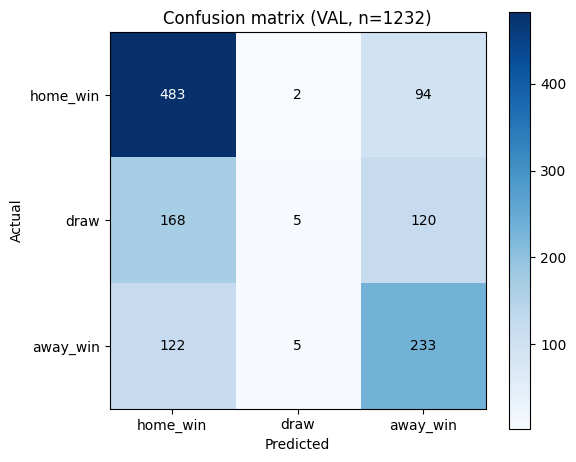


Distribución VAL: Counter({0: 579, 2: 360, 1: 293})
Predicciones VAL: Counter({0: 773, 2: 447, 1: 12})


In [17]:
# Confusion matrix
from collections import Counter
preds_val = p_val.argmax(axis=1)
cm = np.zeros((3, 3), dtype=int)
for yt, yp in zip(y_val, preds_val):
    cm[yt, yp] += 1

labels = ['home_win', 'draw', 'away_win']
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() * 0.6 else 'black')
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion matrix (VAL, n={len(y_val)})')
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(f'\nDistribución VAL: {Counter(y_val.tolist())}')
print(f'Predicciones VAL: {Counter(preds_val.tolist())}')

---
## 8. Comparación contra baselines de Fase 1

In [18]:
# Tabla de comparación (los baselines vienen del paper / Fase 1)
# Si tenés guardadas las métricas exactas en un JSON, lo cargamos. Si no, las dejo hardcodeadas
# del notebook 01_baselines:
baselines_fase1 = {
    'LogReg':         {'log_loss': 0.8610, 'brier': 0.5071, 'ece': 0.0236, 'accuracy': 0.6005},
    'XGBoost':        {'log_loss': 0.8663, 'brier': 0.5105, 'ece': 0.0182, 'accuracy': 0.6026},
    'LightGBM':       {'log_loss': 0.8744, 'brier': 0.5135, 'ece': 0.0250, 'accuracy': 0.5990},
    'ELO solo':       {'log_loss': 1.0102, 'brier': 0.6101, 'ece': 0.0890, 'accuracy': 0.5510},
    'Uniforme':       {'log_loss': 1.0986, 'brier': 0.6667, 'ece': 0.0, 'accuracy': 0.4500},
}

comparison = baselines_fase1.copy()
comparison['D10Sformer (val)']  = {k: metrics_val[k] for k in ['log_loss', 'brier', 'ece', 'accuracy']}
comparison['D10Sformer (test)'] = {k: metrics_test[k] for k in ['log_loss', 'brier', 'ece', 'accuracy']}

import pandas as pd
df_cmp = pd.DataFrame(comparison).T
print('=== Comparación D10Sformer vs Baselines (Fase 1) ===')
print(df_cmp.to_string(float_format=lambda x: f'{x:.4f}'))

# Highlight: ¿le ganamos al mejor baseline en log_loss y accuracy?
best_baseline_ll = min(baselines_fase1[k]['log_loss'] for k in baselines_fase1)
best_baseline_acc = max(baselines_fase1[k]['accuracy'] for k in baselines_fase1)

print(f'\nMejor baseline log_loss:  {best_baseline_ll:.4f}')
print(f'D10Sformer val log_loss:  {metrics_val["log_loss"]:.4f} ({"GANA" if metrics_val["log_loss"] < best_baseline_ll else "pierde"})')
print(f'D10Sformer test log_loss: {metrics_test["log_loss"]:.4f} ({"GANA" if metrics_test["log_loss"] < best_baseline_ll else "pierde"})')
print(f'\nMejor baseline accuracy:  {best_baseline_acc:.4f}')
print(f'D10Sformer val accuracy:  {metrics_val["accuracy"]:.4f} ({"GANA" if metrics_val["accuracy"] > best_baseline_acc else "pierde"})')
print(f'D10Sformer test accuracy: {metrics_test["accuracy"]:.4f} ({"GANA" if metrics_test["accuracy"] > best_baseline_acc else "pierde"})')

=== Comparación D10Sformer vs Baselines (Fase 1) ===
                   log_loss  brier    ece  accuracy
LogReg               0.8610 0.5071 0.0236    0.6005
XGBoost              0.8663 0.5105 0.0182    0.6026
LightGBM             0.8744 0.5135 0.0250    0.5990
ELO solo             1.0102 0.6101 0.0890    0.5510
Uniforme             1.0986 0.6667 0.0000    0.4500
D10Sformer (val)     0.8971 0.5294 0.0493    0.5852
D10Sformer (test)    0.8846 0.5221 0.0400    0.5912

Mejor baseline log_loss:  0.8610
D10Sformer val log_loss:  0.8971 (pierde)
D10Sformer test log_loss: 0.8846 (pierde)

Mejor baseline accuracy:  0.6026
D10Sformer val accuracy:  0.5852 (pierde)
D10Sformer test accuracy: 0.5912 (pierde)


---
## 9. Conclusiones de Fase 4d

- [ ] Tiempo de fine-tuning: _____ min
- [ ] Loss inicial / final: _____ / _____
- [ ] Best val_loss: _____ (paso _____)
- [ ] Métricas finales sobre TEST:
  - log_loss: _____
  - brier: _____
  - ece: _____
  - accuracy: _____
- [ ] ¿Le ganamos al mejor baseline en log_loss? _____
- [ ] ¿Le ganamos en accuracy? _____
- [ ] ¿En ECE? (calibración) _____
- [ ] ¿La confusion matrix muestra que el modelo predice las 3 clases o se concentra en 1-2? _____

**Next:** Fase 5 — evaluación profunda + reliability diagrams + análisis de errores por bucket de ELO + ablation studies (sin pre-train, sin features, etc.).